# Session 5: Introduction to non-linear regression

## Exercise 1: From linear to non-linear

In [3]:
# As usual, we import the libraries we will need during the coding session

import numpy as np
import matplotlib.pyplot as plt

# Recall

In linear regression, the target function $y$ is represented by a **linear** combination of features $x$ such that $y = f(x) + \epsilon$, where $f(x) = \mathbf{w}^T \mathbf{x} = \sum_{i}^d w_i x_i$.

We need to tune the weights $w$ in order to minimise the residuals $\epsilon$ (i.e. the approximation error). For that, we first need to collect some data on the inputs $x$ and the target $y$. 

Then, in the Ordinary Least-Squares approach, the objective is to tune the weights to minimise the euclidean distance between the observations $y$ and the predictions $Xw$:

$w^*= \arg \underset{w}{\min} ||Xw - y||^2_2$

We can use this framework to determine the spring constant of a spring based on noisy data collected in the laboratory (where $x$ is the longitudinal force applied to the spring and $y$ is its length):

K = 1.81
l0 = 10.77
R2 = 0.98


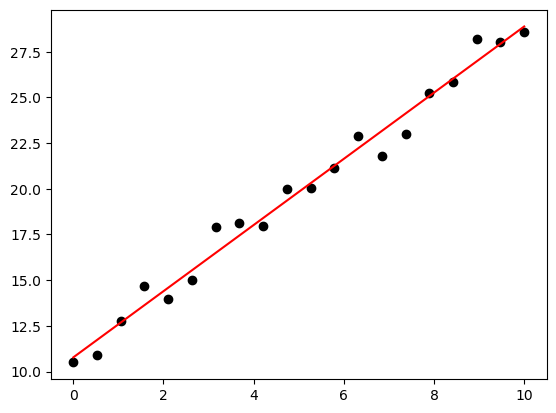

In [ ]:
# Fix the seed for reproducibility
np.random.seed(42)

# We collected n=20 measures
n = 20
x = np.linspace(0, 10, n)

# We already know the spring constant and the initial length given in its datasheet
k = 2
l0 = 10

# We made n noisy observations
msrmt_error = 1
y_obs = l0 + k * x + np.random.normal(0, msrmt_error, size=x.shape)

# Plot the data
plt.scatter(x, y_obs, color='k')

# Then, we determine the Hooke's law parameters by performing a linear regression on the data
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x.reshape(-1, 1), y_obs) # Pay attention to the shape of the data
y_pred = model.predict(x.reshape(-1, 1))
plt.plot(x, y_pred, color='r')
print(f'K = {model.coef_[0]:.2f}')
print(f'l0 = {model.intercept_:.2f}')
print(f'R2 = {model.score(x.reshape(-1, 1), y_obs):.2f}')

# The R2 is very high! But what about the estimation of K? 

Now, imagine that we are measuring the impulse response of a second-order damped system in automation laboratory. We know that our function must take the following form:

$y = A e^{-\alpha x} \sin(\omega x + \phi)$

where $y$ is the response and $x$ the time. $A$, $\alpha$, $\omega$, $\phi$ are our coefficients to determine.

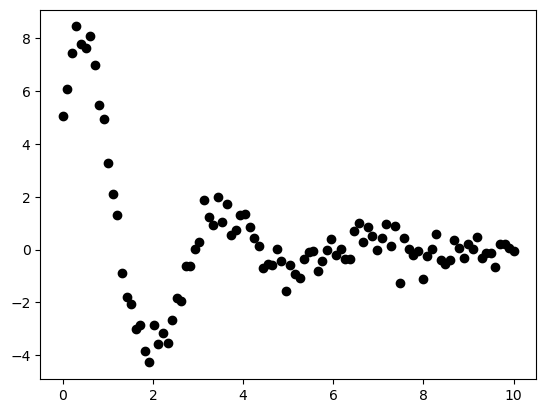

In [50]:
# Fix the seed for reproducibility
np.random.seed(42)

# We collected n=100 measures
n = 100
x = np.linspace(0, 10, n)

# Let's imagine we know the coefficients
A = 10
alpha = 0.5
omega = 2
phi = 0.5

# We made n noisy observations
msrmt_error = 0.5
y_obs = A * np.sin(omega * x + phi) * np.exp(-alpha * x) + np.random.normal(0, msrmt_error, size=x.shape)

# Plot the data
plt.scatter(x, y_obs, color='k')
plt.show()

Then, how do you find the coeficients ? Is it a way to approximate our target using a linear combination of features x ?

Coefficients: [ 8.51021544 -0.73334251  0.40175104]
R2 = 0.56


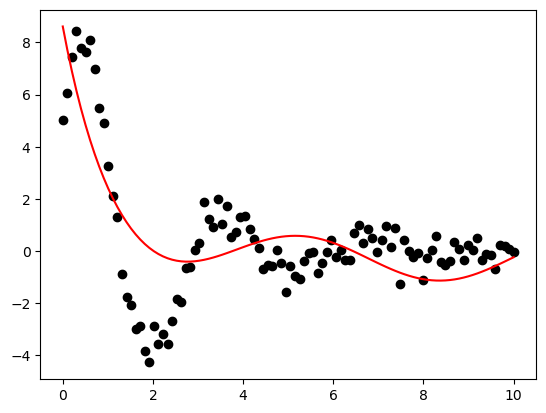

In [53]:
# Try building a good feature matrix that suits our problem !

X = np.column_stack((np.exp(-x), np.sin(x), np.cos(x)))

# Let's copy paste the previous code snippet to see ...
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y_obs) # Pay attention to the shape of the data
y_pred = model.predict(X)

plt.scatter(x, y_obs, color='k')
plt.plot(x, y_pred, color='r')
print(f'Coefficients: {model.coef_}')
print(f'R2 = {model.score(X, y_obs):.2f}')

# Did you succeed ?

Unfortunately, the function to be estimated in this case cannot be expressed as a **linear** combination with our coefficients ... We need to find another way: Non-linear regression!

## Exercise 2: Non-linear regression with gradient descent

A bit of theory ...

Apply it to our non-linear function to regress ...

## Exercise 3: Gradient descent

(Or we put before ? I don't remember the flow)

What's behind this gradient descent algorithm ?